# Feature Store Patterns on Real Case-Study Artifacts

**Chapter 26: MLOps and Governance**
**Docker image**: `ml4t`
**Book Reference**: Chapter 26, Section 26.6
**Prerequisites**: Familiarity with feature engineering and Chapter 25 deployment verification.

**Learning Objectives**:
- Define feature views on real Parquet sources with an explicit entity key,
  event timestamp, and TTL.
- Perform a point-in-time offline join that respects the sealed-holdout
  boundary as a fail-closed governance guard.
- Retrieve an online-style as-of snapshot for inference and quantify the
  training-serving skew that an incorrect timestamp rule introduces.

The notebook demonstrates the core feature-store tasks on the actual
`us_equities_panel` artifacts. A production feature store such as Feast would
automate these steps; here the same controls stay visible and reproducible
inside the repo.

In [1]:
"""Feature Store Patterns on Real Case-Study Artifacts — demonstrate core feature-store tasks on real case-study artifacts."""

'Feature Store Patterns on Real Case-Study Artifacts — demonstrate core feature-store tasks on real case-study artifacts.'

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = "fwd_ret_1d"
TRAINING_START = "2015-10-01"
TRAINING_END = "2015-12-30"
AS_OF_DATE = "2016-01-04"
N_SAMPLE_ASSETS = 8

In [3]:
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from IPython.display import Markdown, display

from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
CODE_ROOT = CASE_DIR.parent.parent  # repo root (case_studies lives at repo root)
SETUP_PATH = CASE_DIR / "config" / "setup.yaml"

print("Feature Store Patterns on Real Case-Study Artifacts")
print("=" * 60)

Feature Store Patterns on Real Case-Study Artifacts


## 1. Define feature views from the real feature tables

The `financial.parquet` and `model_based.parquet` files act as the offline
store. The entity key is `symbol`, and the event timestamp is `timestamp`.

In [4]:
@dataclass
class FeatureViewSpec:
    name: str
    source_path: Path
    entity_key: str
    event_timestamp: str
    ttl_days: int
    feature_columns: list[str]


FINANCIAL_FEATURES = ["past_ret_21d", "vol_21d", "rsi_14", "sharpe_21d"]
MODEL_FEATURES = ["garch_cond_vol", "ffd_log_price", "ffd_log_volume"]

feature_views = [
    FeatureViewSpec(
        name="financial_features",
        source_path=CASE_DIR / "features" / "financial.parquet",
        entity_key="symbol",
        event_timestamp="timestamp",
        ttl_days=1,
        feature_columns=FINANCIAL_FEATURES,
    ),
    FeatureViewSpec(
        name="model_based_features",
        source_path=CASE_DIR / "features" / "model_based.parquet",
        entity_key="symbol",
        event_timestamp="timestamp",
        ttl_days=1,
        feature_columns=MODEL_FEATURES,
    ),
]

In [5]:
feature_registry = pd.DataFrame(
    [
        {
            "feature_view": spec.name,
            "source_path": spec.source_path.relative_to(CODE_ROOT),
            "entity_key": spec.entity_key,
            "event_timestamp": spec.event_timestamp,
            "ttl_days": spec.ttl_days,
            "n_features": len(spec.feature_columns),
        }
        for spec in feature_views
    ]
)
feature_registry

,feature_view,source_path,entity_key,event_timestamp,ttl_days,n_features
0,financial_features,case_studies/us_equities_panel/features/financ...,symbol,timestamp,1,4
1,model_based_features,case_studies/us_equities_panel/features/model_...,symbol,timestamp,1,3


In [6]:
setup = yaml.safe_load(SETUP_PATH.read_text())
holdout_start = pd.Timestamp(setup["evaluation"]["holdout_start"])
holdout_end = pd.Timestamp(setup["evaluation"]["holdout_end"])
# Fail-closed governance guard: the training window must end before the sealed
# holdout starts. A misconfigured TRAINING_END would otherwise silently mix
# pre- and post-holdout data into the offline join.
assert pd.Timestamp(TRAINING_END) < holdout_start, (
    f"TRAINING_END {TRAINING_END} must precede sealed holdout {holdout_start.date()}"
)
print(f"Sealed holdout starts on {holdout_start.date()}")

Sealed holdout starts on 2016-01-01


In [7]:
timeline = pl.scan_parquet(feature_views[0].source_path).select("timestamp").unique().collect()
cv_splits = generate_cv_splits(timeline, case_study_id=CASE_STUDY_ID, label_buffer="1D")
holdout_fold = pl.scan_parquet(feature_views[1].source_path).select(pl.max("fold")).collect().item()
model_windows = [
    (
        split["fold"],
        pd.Timestamp(split["val_start"]).date(),
        pd.Timestamp(split["val_end"]).date(),
    )
    for split in cv_splits
]
model_windows.append((holdout_fold, holdout_start.date(), holdout_end.date()))

## 2. Offline training retrieval with point-in-time correctness

The offline join uses feature values observed on the decision date and the
forward-return label generated after that date. This is the contract a feature
store must preserve. Here features are available after the close on session
$t$, the label is the next-session return, and any position acts no earlier
than the next tradable bar.

In [8]:
def load_training_events(start: str, end: str) -> pl.DataFrame:
    labels = (
        pl.scan_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
        .filter(
            (pl.col("timestamp") >= pl.lit(pd.Timestamp(start).date()))
            & (pl.col("timestamp") <= pl.lit(pd.Timestamp(end).date()))
        )
        .select(
            pl.col("timestamp").cast(pl.Date).alias("timestamp"),
            "symbol",
            pl.col(PRIMARY_LABEL).alias("label"),
        )
        .collect()
    )
    return labels

In [9]:
def load_model_vintage(
    start: str | object,
    end: str | object,
    columns: list[str],
    assets: list[str] | None = None,
) -> pl.DataFrame:
    """Load only the fitted model-feature vintage valid for each decision date."""
    start_date = pd.Timestamp(start).date()
    end_date = pd.Timestamp(end).date()
    source = pl.scan_parquet(feature_views[1].source_path)
    frames = []
    for fold, window_start, window_end in model_windows:
        if window_start > end_date or window_end < start_date:
            continue
        frame = source.filter(
            (pl.col("fold") == fold)
            & pl.col("timestamp").is_between(
                max(start_date, window_start), min(end_date, window_end)
            )
        )
        if assets is not None:
            frame = frame.filter(pl.col("symbol").is_in(assets))
        frames.append(frame.select(["symbol", "timestamp", *columns]))
    result = pl.concat(frames).collect().sort(["timestamp", "symbol"])
    assert not result.select(pl.struct("symbol", "timestamp").is_duplicated().any()).item()
    return result

### Point-in-time join
Join feature values to training events using exact timestamp matching.

In [10]:
def offline_join(events: pl.DataFrame) -> pl.DataFrame:
    assert not events.select(pl.struct("symbol", "timestamp").is_duplicated().any()).item()
    financial = (
        pl.scan_parquet(feature_views[0].source_path)
        .select(["symbol", "timestamp", *FINANCIAL_FEATURES])
        .join(
            events.lazy().select(["symbol", "timestamp"]),
            on=["symbol", "timestamp"],
            how="inner",
        )
        .collect()
    )
    model_based = load_model_vintage(TRAINING_START, TRAINING_END, MODEL_FEATURES).join(
        events.select(["symbol", "timestamp"]), on=["symbol", "timestamp"], how="inner"
    )
    joined = (
        events.join(financial, on=["symbol", "timestamp"], how="left")
        .join(model_based, on=["symbol", "timestamp"], how="left")
        .sort(["timestamp", "symbol"])
    )
    assert joined.height == events.height
    assert not joined.select(pl.struct("symbol", "timestamp").is_duplicated().any()).item()
    return joined.drop_nulls(FINANCIAL_FEATURES + MODEL_FEATURES)


training_events = load_training_events(TRAINING_START, TRAINING_END)
offline_training_set = offline_join(training_events)

print(f"Training events:      {training_events.height:,}")
print(f"Offline joined rows:  {offline_training_set.height:,}")
print(f"Excluded incomplete:  {training_events.height - offline_training_set.height:,}")
offline_training_set.head(5)

Training events:      147,996
Offline joined rows:  147,909
Excluded incomplete:  87


timestamp,symbol,label,past_ret_21d,vol_21d,rsi_14,sharpe_21d,garch_cond_vol,ffd_log_price,ffd_log_volume
date,str,f64,f64,f64,f64,f64,f64,f64,f64
2015-10-01,"""A""",0.027564,-0.026246,0.261409,36.712049,-0.100404,0.190842,0.093824,0.757264
2015-10-01,"""AAL""",-0.014541,0.0,0.336011,39.462258,0.0,0.523469,0.1201,0.371508
2015-10-01,"""AAN""",0.00826,-0.010624,0.272799,41.339916,-0.038944,0.190842,0.151969,0.432061
2015-10-01,"""AAOI""",0.007206,-0.082867,0.70625,42.988241,-0.117334,0.190842,0.154829,0.688491
2015-10-01,"""AAON""",0.019802,-0.031297,0.224387,36.094529,-0.139479,0.190842,0.09,0.462046


## 3. Online-style as-of retrieval

At inference time the system needs the latest known features for each asset at
or before the decision timestamp. The notebook uses the same source tables and
resolves the latest valid snapshot directly.

In [11]:
def sample_assets(n_assets: int) -> list[str]:
    from data import load_us_equities

    # Rank on prior dollar liquidity, not nominal share volume.
    prices = load_us_equities(start_date="2015-10-01", end_date="2015-12-31")
    universe = (
        prices.lazy()
        .sort("symbol", "timestamp")
        .with_columns((pl.col("adj_close") * pl.col("adj_volume")).alias("dollar_volume"))
        .with_columns(pl.col("dollar_volume").rolling_mean(21).over("symbol").alias("adv_21d"))
        .filter(
            (pl.col("timestamp") >= pl.date(2015, 12, 1))
            & (pl.col("timestamp") <= pl.date(2015, 12, 31))
        )
        .group_by("symbol")
        .agg(pl.col("adv_21d").mean().alias("avg_adv_21d"))
        .sort("avg_adv_21d", descending=True)
        .head(n_assets)
        .collect()
    )
    return universe.get_column("symbol").to_list()

### Latest-known snapshot retrieval
Retrieve the most recent valid feature row for each asset at or before the decision date.

In [12]:
def latest_snapshot(
    source_path: Path, as_of_date: str, assets: list[str], columns: list[str]
) -> pl.DataFrame:
    cutoff = pd.Timestamp(as_of_date).date()
    return (
        pl.scan_parquet(source_path)
        .filter((pl.col("timestamp") <= pl.lit(cutoff)) & pl.col("symbol").is_in(assets))
        .select(["symbol", "timestamp", *columns])
        .sort(["symbol", "timestamp"])
        .group_by("symbol")
        .tail(1)
        .collect()
    )

In [13]:
def latest_model_snapshot(as_of_date: str, assets: list[str]) -> pl.DataFrame:
    start = holdout_start if pd.Timestamp(as_of_date) >= holdout_start else pd.Timestamp(as_of_date)
    panel = load_model_vintage(start, as_of_date, MODEL_FEATURES, assets)
    return panel.group_by("symbol").tail(1).sort("symbol")


sampled_assets = sample_assets(N_SAMPLE_ASSETS)
online_financial = latest_snapshot(
    feature_views[0].source_path, AS_OF_DATE, sampled_assets, FINANCIAL_FEATURES
)
online_model = latest_model_snapshot(AS_OF_DATE, sampled_assets)
online_snapshot = online_financial.join(online_model, on=["symbol", "timestamp"], how="inner").sort(
    "symbol"
)

### Online snapshot

In [14]:
online_snapshot

symbol,timestamp,past_ret_21d,vol_21d,rsi_14,sharpe_21d,garch_cond_vol,ffd_log_price,ffd_log_volume
str,date,f64,f64,f64,f64,f64,f64,f64
"""AAPL""",2016-01-04,-0.093997,0.24824,34.324922,-0.378655,0.277925,0.155662,1.222692
"""AMZN""",2016-01-04,-0.057721,0.322075,40.362438,-0.179216,0.339672,0.236471,1.476786
"""FB""",2016-01-04,-0.036297,0.244539,42.246885,-0.148429,0.254305,0.209925,1.474668
"""GE""",2016-01-04,0.032406,0.150843,54.797536,0.214832,0.161581,0.142864,0.989825
"""GOOG""",2016-01-04,-0.026942,0.208622,46.880158,-0.129142,0.154684,0.393863,1.599194
"""GOOGL""",2016-01-04,-0.023668,0.212159,46.769435,-0.111557,0.249022,0.255882,1.206573
"""MSFT""",2016-01-04,-0.007426,0.23678,49.128828,-0.031363,0.247649,0.164954,1.286004
"""NFLX""",2016-01-04,-0.147134,0.353459,36.591332,-0.416269,0.536699,0.175251,1.286394


## 4. Quantify training-serving skew

The failure mode is simple: serve the *next* available snapshot instead of the
last known snapshot. That is only one day of look-ahead, but it still changes
the feature vector and leaks future information into inference.

In [15]:
def leaked_snapshot(as_of_date: str, assets: list[str]) -> pl.DataFrame:
    cutoff = pd.Timestamp(as_of_date).date()
    future_end = min((pd.Timestamp(cutoff) + pd.Timedelta(days=7)).date(), holdout_end.date())
    financial = (
        pl.scan_parquet(feature_views[0].source_path)
        .filter((pl.col("timestamp") > pl.lit(cutoff)) & pl.col("symbol").is_in(assets))
        .select(["symbol", "timestamp", *FINANCIAL_FEATURES])
        .sort(["symbol", "timestamp"])
        .group_by("symbol")
        .head(1)
    )
    model_based = (
        load_model_vintage(cutoff, future_end, MODEL_FEATURES, assets)
        .lazy()
        .filter(pl.col("timestamp") > pl.lit(cutoff))
        .sort(["symbol", "timestamp"])
        .group_by("symbol")
        .head(1)
    )
    return (
        financial.join(model_based, on=["symbol", "timestamp"], how="inner")
        .collect()
        .sort("symbol")
    )


future_snapshot = leaked_snapshot(AS_OF_DATE, sampled_assets)
comparison = (
    online_snapshot.rename({col: f"{col}_correct" for col in FINANCIAL_FEATURES + MODEL_FEATURES})
    .join(
        future_snapshot.rename(
            {col: f"{col}_leaked" for col in FINANCIAL_FEATURES + MODEL_FEATURES}
        ),
        on="symbol",
        how="inner",
    )
    .to_pandas()
)

In [16]:
skew_rows = []
for column in FINANCIAL_FEATURES + MODEL_FEATURES:
    skew_rows.append(
        {
            "feature": column,
            "mean_abs_delta": np.abs(
                comparison[f"{column}_leaked"] - comparison[f"{column}_correct"]
            ).mean(),
            "max_abs_delta": np.abs(
                comparison[f"{column}_leaked"] - comparison[f"{column}_correct"]
            ).max(),
        }
    )
skew_table = pd.DataFrame(skew_rows).sort_values("mean_abs_delta", ascending=False)
skew_table

,feature,mean_abs_delta,max_abs_delta
2,rsi_14,1.623490,4.468562
6,ffd_log_volume,0.640137,0.837551
3,sharpe_21d,0.050160,0.100176
4,garch_cond_vol,0.016534,0.065328
0,past_ret_21d,0.012581,0.023109
5,ffd_log_price,0.012447,0.022439
1,vol_21d,0.004468,0.009601


In [17]:
largest_skew = skew_table.iloc[0]
display(
    Markdown(
        f"**Finding**: `{largest_skew['feature']}` moves most under the deliberately "
        f"leaked timestamp rule (mean absolute delta {largest_skew['mean_abs_delta']:.4g}). "
        "A feature store prevents even a one-session look-ahead from reaching production."
    )
)

**Finding**: `rsi_14` moves most under the deliberately leaked timestamp rule (mean absolute delta 1.623). A feature store prevents even a one-session look-ahead from reaching production.

## 5. Source-lineage view

A feature registry needs more than names. Operators need to know where a view
came from, how many rows it contains, and what date range it covers.

In [18]:
lineage_rows = []
for spec in feature_views:
    stats = (
        pl.scan_parquet(spec.source_path)
        .select(
            pl.len().alias("rows"),
            pl.min("timestamp").alias("min_date"),
            pl.max("timestamp").alias("max_date"),
            pl.struct("symbol", "timestamp").n_unique().alias("unique_keys"),
        )
        .collect()
        .row(0)
    )
    lineage_rows.append(
        {
            "feature_view": spec.name,
            "rows": stats[0],
            "start": pd.Timestamp(stats[1]).date(),
            "end": pd.Timestamp(stats[2]).date(),
            "unique_keys": stats[3],
            "features": ", ".join(spec.feature_columns),
        }
    )
lineage_table = pd.DataFrame(lineage_rows)
lineage_table

,feature_view,rows,start,end,unique_keys,features
0,financial_features,9208607,1990-03-01,2018-03-27,9208607,"past_ret_21d, vol_21d, rsi_14, sharpe_21d"
1,model_based_features,63221523,1990-02-02,2018-03-27,9274754,"garch_cond_vol, ffd_log_price, ffd_log_volume"


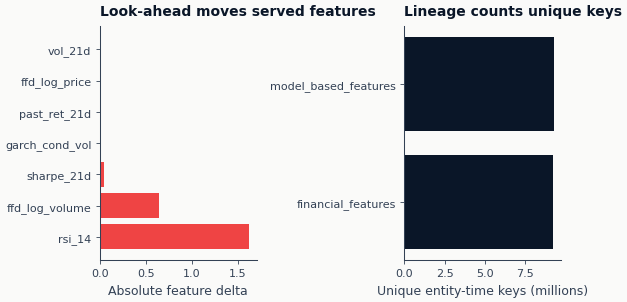

In [19]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"])

ax1 = axes[0]
ax1.barh(skew_table["feature"], skew_table["mean_abs_delta"], color=COLORS["negative"])
add_message_title(ax1, "Look-ahead moves served features")
ax1.set_xlabel("Absolute feature delta")

ax2 = axes[1]
ax2.barh(
    lineage_table["feature_view"],
    lineage_table["unique_keys"] / 1_000_000,
    color=COLORS["blue"],
)
add_message_title(ax2, "Lineage counts unique keys")
ax2.set_xlabel("Unique entity-time keys (millions)")

plt.tight_layout()
fig.show()

### Feature registry

In [20]:
feature_registry

,feature_view,source_path,entity_key,event_timestamp,ttl_days,n_features
0,financial_features,case_studies/us_equities_panel/features/financ...,symbol,timestamp,1,4
1,model_based_features,case_studies/us_equities_panel/features/model_...,symbol,timestamp,1,3


### Lineage table

In [21]:
lineage_table

,feature_view,rows,start,end,unique_keys,features
0,financial_features,9208607,1990-03-01,2018-03-27,9208607,"past_ret_21d, vol_21d, rsi_14, sharpe_21d"
1,model_based_features,63221523,1990-02-02,2018-03-27,9274754,"garch_cond_vol, ffd_log_price, ffd_log_volume"


**Trading implication**: The operational contract is simple. Training joins
use the last valid feature values at the decision timestamp, serving uses the
same rule online, and the registry makes the source tables auditable. A tool
like Feast automates these controls, but the control itself is what matters.

## Key Takeaways

1. Feature stores enforce point-in-time correctness by joining only the feature vintage fitted for each decision timestamp.
2. Training-serving skew from using the wrong timestamp rule is quantifiable — even one day of look-ahead changes the feature vector.
3. A source-lineage registry makes each feature view auditable — operators know the source, date range, and row count.

**Next**: See `05b_feast_live` for the same workflow automated with Feast, or `06_mlflow_experiments` for experiment tracking.